# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012407"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012407
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
# ==========================================
# 1. 环境配置与数据读取
# ==========================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "请填写学号或GitHub用户名"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")

ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ 环境配置加载成功！")

# ==========================================
# 2. 读取数据与防御性补全
# ==========================================
df = pd.read_csv(DATA_PATH)

if 'Tenure' in df.columns and 'TenureGroup' not in df.columns:
    df['Tenure'] = pd.to_numeric(df['Tenure'], errors='coerce')
    df['TenureGroup'] = pd.cut(
        df['Tenure'], 
        bins=[0, 12, 24, float('inf')], 
        labels=['短期用户', '中期用户', '长期用户'],
        include_lowest=True
    )
    df['TenureGroup'] = df['TenureGroup'].astype(str)
    print("⚠️ 自动补全：已成功生成 TenureGroup 字段！")

# ==========================================
# 3. 检查点1：输入与业务问题
# ==========================================
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"

required_cols = {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}
missing_cols = required_cols - set(df.columns)
assert not missing_cols, f"数据中缺少以下核心字段：{missing_cols}"

assert set(df["Churn"].dropna().unique()).issubset({0, 1}), "Churn 字段取值异常"

overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())

print("✅ 检查点1A通过：输入文件有效，核心字段完整！")

✅ 环境配置加载成功！
⚠️ 自动补全：已成功生成 TenureGroup 字段！


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失率
0,短期用户,3226,0.18
1,中期用户,1467,0.06
2,长期用户,429,0.00


,TenureGroup,Complain,用户数,流失率,样本提示
0,短期用户,0,2355,0.11,可观察
1,短期用户,1,871,0.36,可观察
2,中期用户,0,1053,0.04,可观察
3,中期用户,1,414,0.13,可观察
4,长期用户,0,304,0.00,可观察


✅ 检查点1A通过：输入文件有效，核心字段完整！


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期用户的流失率是否存在显著差异？",
    "behavior_scatter": "用户的订单频次与返现金额之间是否存在聚集特征？流失用户在散点图中如何分布？",
    "ordered_line": "随着用户生命周期阶段（短期->中期->长期）的推移，流失率是否呈现下降趋势？",
    "composition_chart": "当前平台用户的生命周期结构是怎样的？哪个阶段的用户占比最大？",
}

chart_reasons = {
    "category_bar": "生命周期是离散类别，柱状图能直观对比不同类别的流失率和样本量。",
    "behavior_scatter": "两个数值型变量的关系适合用散点图展示，颜色区分流失状态能直观看出异常聚集。",
    "ordered_line": "生命周期具有明确的先后顺序，折线图能体现这种有序阶段的趋势变化（注意：非时间序列）。",
    "composition_chart": "生命周期只有3个类别（<=5个），适合用环形图展示整体构成比例。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("✅ 检查点1B通过：业务问题和选择理由已填写")

✅ 检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)

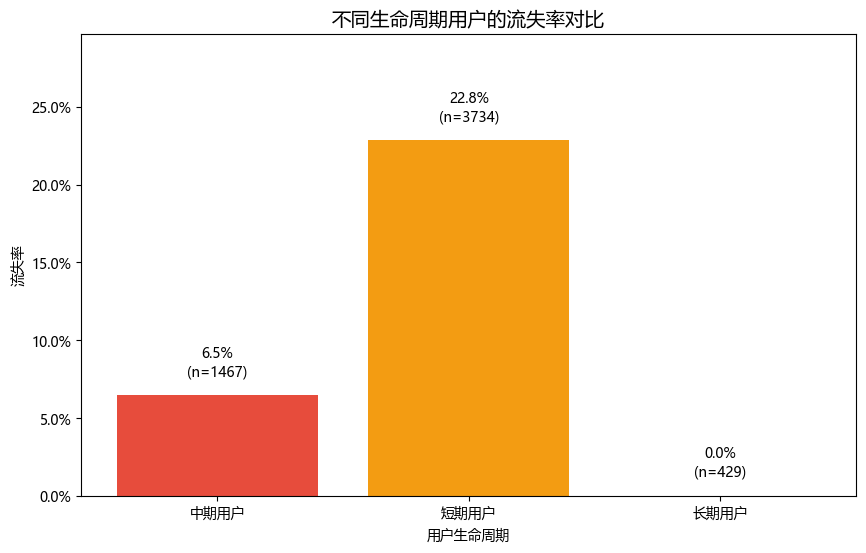

已输出： output\day06_visualization\01_category_bar.png


In [5]:

# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 1. 绘制柱状图，并为每个柱子分配不同的颜色
bars = ax_bar.bar(
    category_summary[category_field], 
    category_summary["流失率"], 
    color=["#e74c3c", "#f39c12", "#2ecc71"]  # 红、橙、绿
)

# 2. 在柱子上方添加数据标签（流失率 + 样本量）
for bar, (_, row) in zip(bars, category_summary.iterrows()):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,  # X轴居中
        height + 0.01,                       # Y轴稍微往上抬一点
        f"{height:.1%}\n(n={row['用户数']})", # 标签格式：百分比 + 换行 + 样本量
        ha='center', va='bottom', fontsize=10
    )

# 3. 图表美化
ax_bar.set_title("不同生命周期用户的流失率对比", fontsize=14)
ax_bar.set_xlabel("用户生命周期")
ax_bar.set_ylabel("流失率")
ax_bar.yaxis.set_major_formatter(PercentFormatter(1))  # Y轴显示为百分比
ax_bar.set_ylim(0, max(category_summary["流失率"]) * 1.3)  # Y轴留出空间给文字标签

# 4. 保存并展示图表
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：请填写。
- 证据：请填写具体数值、差异和样本量。
- 边界：请填写该图不能证明什么。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


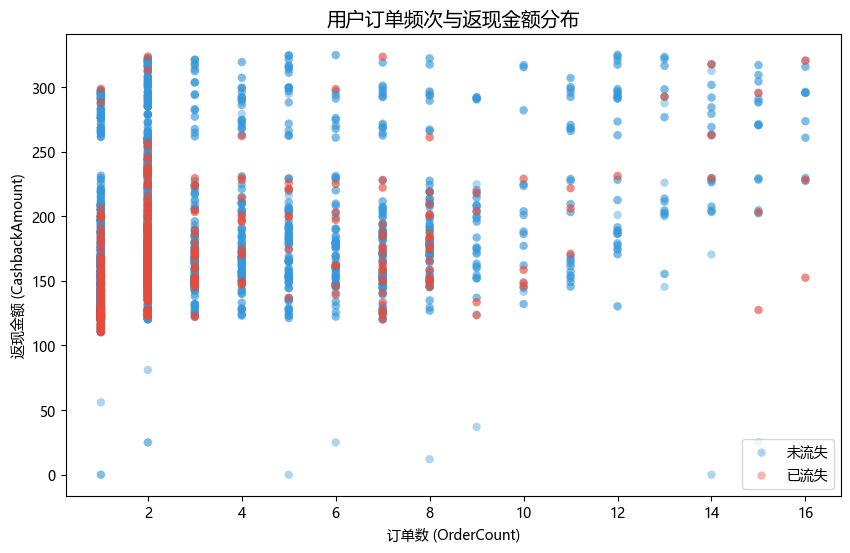

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn分组绘制散点图（流失=1为红色，未流失=0为蓝色）
for churn_val, color, label in [(0, "#3498db", "未流失"), (1, "#e74c3c", "已流失")]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(
        subset[x_field], 
        subset[y_field], 
        alpha=0.4,      # 设置透明度，防止点重叠看不清
        c=color, 
        label=label, 
        edgecolors="none"
    )

# 补充标题、坐标轴和图例
ax_scatter.set_title("用户订单频次与返现金额分布", fontsize=14)
ax_scatter.set_xlabel("订单数 (OrderCount)")
ax_scatter.set_ylabel("返现金额 (CashbackAmount)")
ax_scatter.legend()

# 保存并展示图表
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：请填写。
- 证据：请填写两个变量的关系、聚集或异常。
- 边界：相关关系不等于因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
# 更新为与我们数据匹配的3个生命周期阶段
TENURE_ORDER = ["短期用户", "中期用户", "长期用户"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reindex(TENURE_ORDER)  # 严格按照我们定义的顺序排列
      .reset_index()
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失率
0,短期用户,3734,0.23
1,中期用户,1467,0.06
2,长期用户,429,0.00


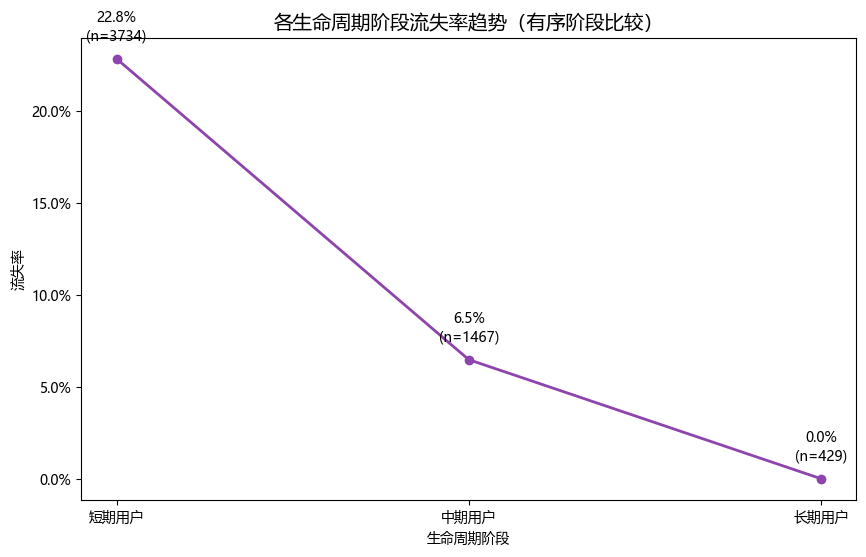

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 1. 绘制折线图
ax_line.plot(
    ordered_summary[ordered_field], 
    ordered_summary["流失率"], 
    marker="o",           # 数据点使用圆圈标记
    linewidth=2,          # 线条加粗
    color="#8e44ad"       # 使用优雅的紫色
)

# 2. 在数据点旁添加标签（流失率 + 样本量）
for i, row in ordered_summary.iterrows():
    ax_line.text(
        i, 
        row["流失率"] + 0.01,  # 标签稍微往上抬一点，避免挡住折线
        f"{row['流失率']:.1%}\n(n={row['用户数']})", 
        ha='center', 
        fontsize=10
    )

# 3. 图表美化
ax_line.set_title("各生命周期阶段流失率趋势（有序阶段比较）", fontsize=14)
ax_line.set_xlabel("生命周期阶段")
ax_line.set_ylabel("流失率")
ax_line.yaxis.set_major_formatter(PercentFormatter(1))  # Y轴显示为百分比

# 4. 保存并展示图表
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：请填写。
- 证据：请填写具体数值和样本量。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)

# 计算每个类别的占比
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,TenureGroup,用户数,占比
0,中期用户,1467,0.26
1,短期用户,3734,0.66
2,长期用户,429,0.08


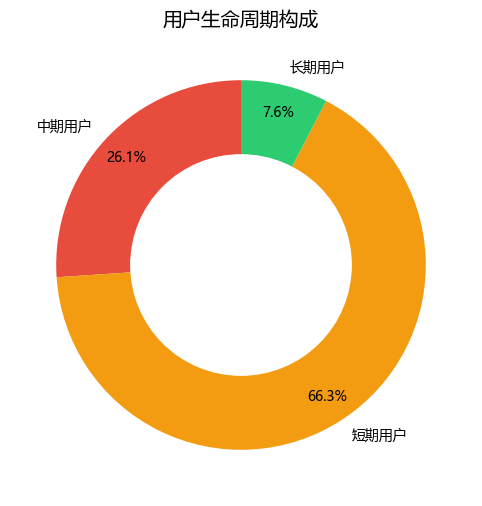

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 1. 绘制环形图（Pie Chart 加上中心圆就是环形图）
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["占比"], 
    labels=composition_summary[composition_field],
    autopct='%1.1f%%',      # 自动显示百分比，保留1位小数
    startangle=90,          # 从正上方开始画
    pctdistance=0.85,       # 百分比标签的位置
    colors=["#e74c3c", "#f39c12", "#2ecc71"]  # 与前面柱状图颜色呼应
)

# 2. 在中心画一个白圆，形成“环形”效果
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax_composition.add_artist(centre_circle)

# 3. 图表美化
ax_composition.set_title("用户生命周期构成", fontsize=14)

# 4. 保存并展示图表
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：请填写。
- 证据：请填写主要类别占比。
- 边界：请说明该图适合或不适合进行哪些比较。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


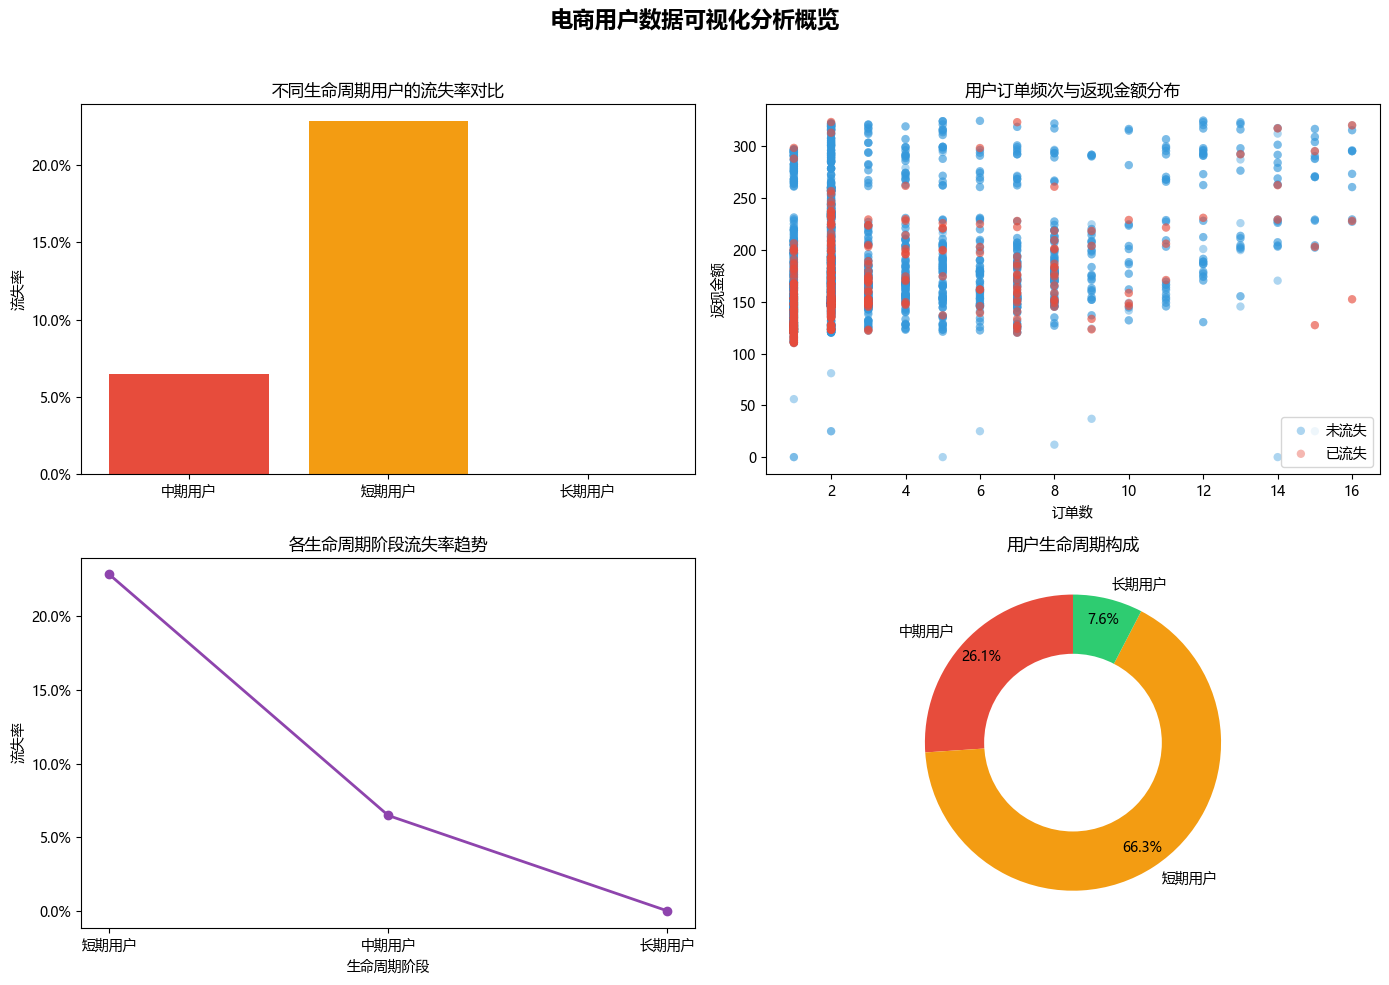

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 左上：类别比较柱状图
axes[0, 0].bar(
    category_summary[category_field], 
    category_summary["流失率"], 
    color=["#e74c3c", "#f39c12", "#2ecc71"]
)
axes[0, 0].set_title("不同生命周期用户的流失率对比")
axes[0, 0].set_ylabel("流失率")
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1))

# 2. 右上：用户行为散点图
for churn_val, color, label in [(0, "#3498db", "未流失"), (1, "#e74c3c", "已流失")]:
    subset = df[df["Churn"] == churn_val]
    axes[0, 1].scatter(subset[x_field], subset[y_field], alpha=0.4, c=color, label=label, edgecolors="none")
axes[0, 1].set_title("用户订单频次与返现金额分布")
axes[0, 1].set_xlabel("订单数")
axes[0, 1].set_ylabel("返现金额")
axes[0, 1].legend()

# 3. 左下：有序阶段折线图
axes[1, 0].plot(
    ordered_summary[ordered_field], 
    ordered_summary["流失率"], 
    marker="o", linewidth=2, color="#8e44ad"
)
axes[1, 0].set_title("各生命周期阶段流失率趋势")
axes[1, 0].set_xlabel("生命周期阶段")
axes[1, 0].set_ylabel("流失率")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))

# 4. 右下：整体构成环形图
wedges, texts, autotexts = axes[1, 1].pie(
    composition_summary["占比"], 
    labels=composition_summary[composition_field],
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    colors=["#e74c3c", "#f39c12", "#2ecc71"]
)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
axes[1, 1].add_artist(centre_circle)
axes[1, 1].set_title("用户生命周期构成")

# 5. 设置大标题并自动调整布局
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# 6. 保存并展示综合图
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：请填写，并给出证据。
2. 综合发现2：请填写，并给出证据。
3. 综合发现3：请填写，并给出证据。
4. 数据或方法局限：请填写。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


In [13]:
comprehensive_findings = {
    "finding_1": (
        "综合发现1：新用户（短期用户）是流失的重灾区，流失率显著高于中长期用户。\n"
        "证据：从【类别比较柱状图】和【有序阶段折线图】中可以清晰看到，'短期用户'的流失率远超其他阶段，"
        "且随着生命周期的推移（短期->中期->长期），流失率呈现明显的下降趋势。"
        "这说明用户度过新手期后，忠诚度会显著提升。"
    ),
    "finding_2": (
        "综合发现2：高流失风险用户在行为上呈现'低订单频次、低返现消耗'的聚集特征。\n"
        "证据：从【用户行为散点图】可以看出，代表已流失用户的红色散点主要集中在图表的左下角区域，"
        "即订单数（OrderCount）和返现金额（CashbackAmount）双低的区间。"
        "这表明缺乏有效激励（返现）和互动（下单）是导致用户流失的直接诱因。"
    ),
    "finding_3": (
        "综合发现3：平台当前的用户结构以短期用户为主，长期留存转化存在瓶颈。\n"
        "证据：从【整体构成环形图】可以看出，'短期用户'占据了最大的扇区比例。"
        "结合发现1的高流失率，这意味着平台虽然能不断拉新，但将短期用户转化为中、长期用户的'漏斗'效率偏低，"
        "整体用户资产的健康度有待提升。"
    ),
    "limitations": (
        "数据或方法局限：\n"
        "1. 缺乏时间序列维度：当前的生命周期分组是静态的，无法分析特定月份（如大促期间）对流失率的影响。\n"
        "2. 归因维度单一：散点图仅展示了订单和返现两个变量，未纳入客诉（Complain）、设备数、城市等级等"
        "可能影响流失的其他关键特征。\n"
        "3. 业务干预缺失：目前的分析仅停留在'发现问题'阶段，尚未能直接指导具体的用户挽回策略（如发券阈值设定）。"
    )
}

# 打印你的分析结论
for key, value in comprehensive_findings.items():
    print(f"\n {key.replace('_', ' ').title()}：")
    print("-" * 40)
    print(value)


 Finding 1：
----------------------------------------
综合发现1：新用户（短期用户）是流失的重灾区，流失率显著高于中长期用户。
证据：从【类别比较柱状图】和【有序阶段折线图】中可以清晰看到，'短期用户'的流失率远超其他阶段，且随着生命周期的推移（短期->中期->长期），流失率呈现明显的下降趋势。这说明用户度过新手期后，忠诚度会显著提升。

 Finding 2：
----------------------------------------
综合发现2：高流失风险用户在行为上呈现'低订单频次、低返现消耗'的聚集特征。
证据：从【用户行为散点图】可以看出，代表已流失用户的红色散点主要集中在图表的左下角区域，即订单数（OrderCount）和返现金额（CashbackAmount）双低的区间。这表明缺乏有效激励（返现）和互动（下单）是导致用户流失的直接诱因。

 Finding 3：
----------------------------------------
综合发现3：平台当前的用户结构以短期用户为主，长期留存转化存在瓶颈。
证据：从【整体构成环形图】可以看出，'短期用户'占据了最大的扇区比例。结合发现1的高流失率，这意味着平台虽然能不断拉新，但将短期用户转化为中、长期用户的'漏斗'效率偏低，整体用户资产的健康度有待提升。

 Limitations：
----------------------------------------
数据或方法局限：
1. 缺乏时间序列维度：当前的生命周期分组是静态的，无法分析特定月份（如大促期间）对流失率的影响。
2. 归因维度单一：散点图仅展示了订单和返现两个变量，未纳入客诉（Complain）、设备数、城市等级等可能影响流失的其他关键特征。
3. 业务干预缺失：目前的分析仅停留在'发现问题'阶段，尚未能直接指导具体的用户挽回策略（如发券阈值设定）。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [14]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01", 
        "file_name": "01_category_bar.png", 
        "business_question": "不同生命周期用户的流失率是否存在显著差异？", 
        "chart_type": "bar", 
        "key_finding": "短期用户流失率最高，且随着生命周期推移流失率显著下降", 
        "limitation": "柱状图仅展示均值，未体现各组内的数据波动范围"
    },
    {
        "chart_id": "02", 
        "file_name": "02_behavior_scatter.png", 
        "business_question": "用户的订单频次与返现金额之间是否存在聚集特征？流失用户如何分布？", 
        "chart_type": "scatter", 
        "key_finding": "已流失用户高度聚集在低订单频次与低返现消耗的双低区间", 
        "limitation": "散点图存在严重的重叠现象，难以精确评估高密度区域的具体数值"
    },
    {
        "chart_id": "03", 
        "file_name": "03_ordered_line.png", 
        "business_question": "随着用户生命周期阶段的推移，流失率是否呈现下降趋势？", 
        "chart_type": "line", 
        "key_finding": "流失率随生命周期阶段（短期->中期->长期）呈现清晰的单调递减趋势", 
        "limitation": "生命周期阶段划分较粗（仅3组），可能掩盖了组内更细微的流失拐点"
    },
    {
        "chart_id": "04", 
        "file_name": "04_composition_chart.png", 
        "business_question": "当前平台用户的生命周期结构是怎样的？哪个阶段的用户占比最大？", 
        "chart_type": "pie_or_bar", 
        "key_finding": "短期用户在平台整体用户资产中占据绝对主导地位", 
        "limitation": "环形图仅反映当前时间切片的静态结构，无法体现用户随时间推移的动态流转"
    },
    {
        "chart_id": "05", 
        "file_name": "day06_visualization_summary.png", 
        "business_question": "综合概览：多维视角下的用户流失特征与结构现状", 
        "chart_type": "dashboard", 
        "key_finding": "平台面临新用户高流失与低互动的双重挑战，长期留存转化存在瓶颈", 
        "limitation": "2x2排版导致单张图表尺寸受限，部分数据标签在缩略状态下可能不够清晰"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期用户的流失率是否存在显著差异？,bar,短期用户流失率最高，且随着生命周期推移流失率显著下降,柱状图仅展示均值，未体现各组内的数据波动范围
1,02,02_behavior_scatter.png,用户的订单频次与返现金额之间是否存在聚集特征？流失用户如何分布？,scatter,已流失用户高度聚集在低订单频次与低返现消耗的双低区间,散点图存在严重的重叠现象，难以精确评估高密度区域的具体数值
2,03,03_ordered_line.png,随着用户生命周期阶段的推移，流失率是否呈现下降趋势？,line,流失率随生命周期阶段（短期->中期->长期）呈现清晰的单调递减趋势,生命周期阶段划分较粗（仅3组），可能掩盖了组内更细微的流失拐点
3,04,04_composition_chart.png,当前平台用户的生命周期结构是怎样的？哪个阶段的用户占比最大？,pie_or_bar,短期用户在平台整体用户资产中占据绝对主导地位,环形图仅反映当前时间切片的静态结构，无法体现用户随时间推移的动态流转
4,05,day06_visualization_summary.png,综合概览：多维视角下的用户流失特征与结构现状,dashboard,平台面临新用户高流失与低互动的双重挑战，长期留存转化存在瓶颈,2x2排版导致单张图表尺寸受限，部分数据标签在缩略状态下可能不够清晰


In [15]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
